In [ ]:
import gizmo_analysis as gizmo
import utilities as ut

import numpy as np
 
import matplotlib.pyplot as plt

In [3]:
simulation_directory = '/bighome/jbailin/FIRE-m12b/' 

part = gizmo.io.Read.read_snapshots('star', 'index', 453, simulation_directory, assign_hosts_rotation=True,
                                        assign_hosts=True)

SpeciesProfile = ut.particle.SpeciesProfileClass(

limits=[0, 20], width=1, log_scale=False, dimension_number=3)



# in utilities.simulation.Snapshot():
* reading:  bighome/jbailin/FIRE-m12b/snapshot_times.txt

* reading:  bighome/jbailin/FIRE-m12b/snapshot_scalefactors.txt

* reading:  bighome/jbailin/FIRE-m12b/snapshot_scale-factors.txt

cannot find file of snapshot times in /bighome/jbailin/FIRE-m12b/

# in gizmo_analysis.gizmo_io.Read():
* reading header from:  bighome/jbailin/FIRE-m12b/output/snapdir_453/snapshot_453.0.hdf5
  snapshot contains the following number of particles:
    dark      (id = 1): 74537000 particles
    dark2     (id = 2): 6750970 particles
    gas       (id = 0): 62307920 particles
    star      (id = 4): 12871441 particles
    blackhole (id = 5): 0 particles



* reading the following
  species: ['star']

* reading particles from:
    snapshot_453.0.hdf5
    snapshot_453.1.hdf5
    snapshot_453.2.hdf5
    snapshot_453.3.hdf5
    snapshot_453.4.hdf5
    snapshot_453.5.hdf5
    snapshot_453.6.hdf5
    snapshot_453.7.hdf5

! cannot find MUSIC config file:  bighome/jbailin/FIRE-m12b/*/*.conf
! missing cosmological parameters, assuming cosmology from AGORA
  assuming omega_baryon = 0.0455
  assuming sigma_8 = 0.807
  assuming n_s = 0.961

* checking sanity of particle properties
! warning: star mass [min, med, max] = [3207.072, 5450.528, 23714.801]

! cannot read file containing hosts coordinates
  instead will assign hosts via iterative zoom on particle mass

# in utilities.particle.get_center_positions():
* assigning position for 1 center/host, via iterative zoom-in on star particle mass
  host1 position = (39575.07, 41722.10, 39586.99) [kpc comoving]

# in utilities.particle.get_center_velocities_or_accelerations():
* assigning velocity for 1 c

In [4]:
pro = SpeciesProfile.get_sum_profiles(part, 'star', 'mass')

pro.keys()

pro['star'].keys()


# in utilities.particle.SpeciesProfile():
  input 12871441 distances - 10729523 (83.4%) are within limits = [0.000, 20.000]


dict_keys(['sum', 'sum.cum', 'log sum', 'log sum.cum', 'density', 'log density', 'density.cum', 'log density.cum', 'density.norm', 'log density.norm', 'density*r', 'log density*r', 'density*r^2', 'log density*r^2', 'fraction', 'log fraction', 'fraction.cum', 'log fraction.cum', 'distance.mid', 'distance.cum', 'log distance.mid', 'log distance.cum', 'sum.fraction', 'sum.cum.fraction', 'vel.circ', 'vel.circ2'])

In [5]:
print(part['star'].prop('mass'))

[6210.8623 5098.7754 5030.047  ... 5361.6626 5121.082  5291.9272]


In [6]:
r     = part['star'].prop('host.distance.total') # Total distance from host center.
R      = part['star'].prop('host.distance.principal.cylindrical')[:,0] # Cylindrical radius in host principal frame.
x        = part['star'].prop('host.distance.principal')[:,0] # X coordinate in host principal frame.
y        = part['star'].prop('host.distance.principal')[:,1] # Y coordinate in host principal frame.
z        = part['star'].prop('host.distance.principal')[:,2] # Z coordinate in host principal frame.
mass     = part['star'].prop('mass') # Mass of star particles.

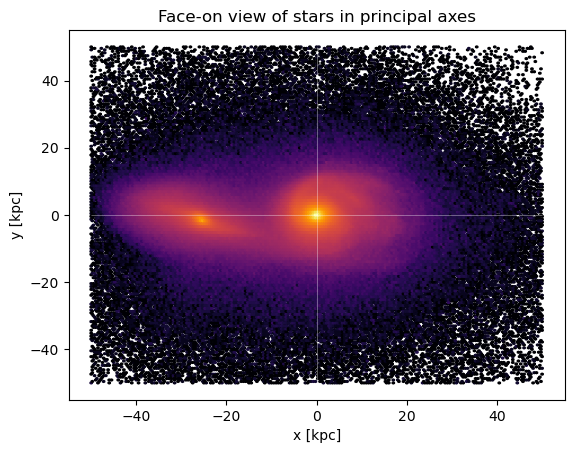

In [7]:
plt.hexbin(x, y, gridsize=200, cmap='inferno', bins='log', mincnt=1,extent=[-50,50,-50,50]) # Creating a hexbin plot of star particles in the principal axes.
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title('Face-on view of stars in principal axes')
plt.hlines(0, color='w', lw=0.5, xmin=-50, xmax=50,alpha=0.5)
plt.vlines(0, color='w', lw=0.5, ymin=-50, ymax=50,alpha=0.5)

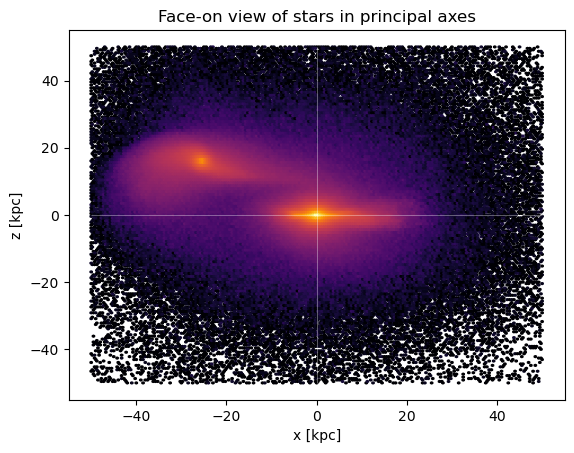

In [8]:
plt.hexbin(x, z, gridsize=200, cmap='inferno', bins='log', mincnt=1,extent=[-50,50,-50,50]) # Creating a hexbin plot of star particles in the principal axes.
plt.xlabel('x [kpc]')
plt.ylabel('z [kpc]')
plt.title('Face-on view of stars in principal axes')
plt.hlines(0, color='w', lw=0.5, xmin=-50, xmax=50,alpha=0.5)
plt.vlines(0, color='w', lw=0.5, ymin=-50, ymax=50,alpha=0.5)

Text(0.5, 1.0, 'Face-on view of stars in principal axes')

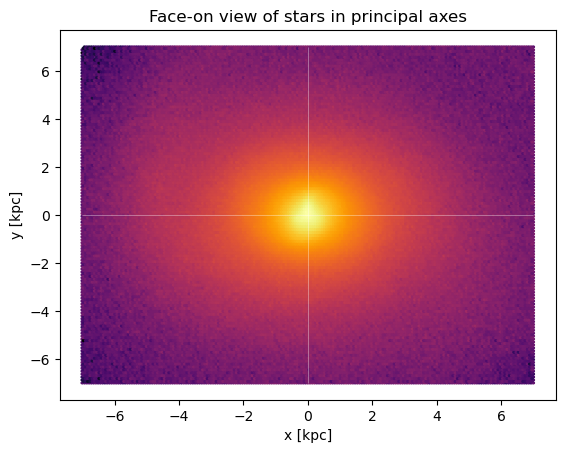

In [9]:
plt.hexbin(x, y, gridsize=200, cmap='inferno', bins='log', mincnt=1,extent=[-7,7,-7,7])
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.vlines(0, color='w', lw=0.5, ymin=-7, ymax=7,alpha=0.5)
plt.hlines(0, color='w', lw=0.5, xmin=-7, xmax=7,alpha=0.5)
plt.title('Face-on view of stars in principal axes')

Text(0.5, 1.0, 'Edge-on view of stars in principal axes')

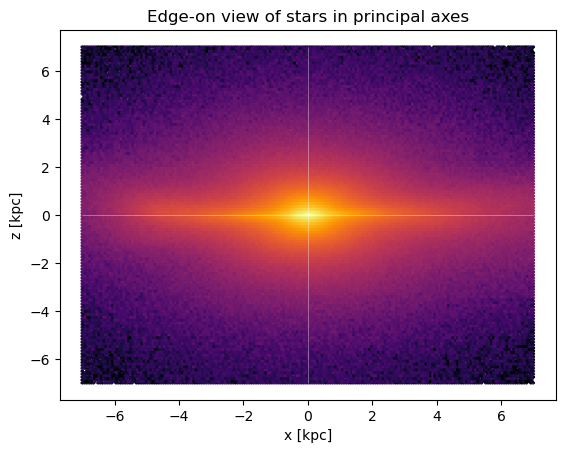

In [10]:
plt.hexbin(x, z, gridsize=200, cmap='inferno', bins='log', mincnt=1,extent=[-7,7,-7,7])
plt.xlabel('x [kpc]')
plt.ylabel('z [kpc]')
plt.vlines(0, color='w', lw=0.5, ymin=-7, ymax=7,alpha=0.5)
plt.hlines(0, color='w', lw=0.5, xmin=-7, xmax=7,alpha=0.5)
plt.title('Edge-on view of stars in principal axes')

In [11]:
###Old Method: Not Used Anymore###

def old_mehthod():

    part['star']['L']=np.cross(part['star'].prop('host.distance'),part['star'].prop('host.velocity'))*part['star'].prop('mass')[:,np.newaxis]

    part['star']['Lz']=part['star']['L'][:,2]

    part['star']['Lmag']=np.linalg.norm(part['star']['L'],axis=1)

    part['star']['Lz_over_L']=part['star']['Lz']/part['star']['Lmag']

    rinner=4

    router=5

    disk_particle_mask = np.logical_and(part['star'].prop('host.distance.total') > rinner,part['star'].prop('host.distance.total') < router)

    print(len(disk_particle_mask),np.sum(disk_particle_mask))

    Ldisk=np.sum(part['star']['L'][disk_particle_mask,:],axis=0)

    Lmag=np.linalg.norm(part['star']['L'][:,:],axis=1)

    Lunit= Ldisk / np.linalg.norm(Ldisk)

    part['star']['L_dot_disk']=np.sum(part['star']['L']*Lunit,axis=1)/Lmag

    part['star']['theta']=np.arccos((part['star']['L_dot_disk']))*(180/np.pi)

    gizmo.plot.plot_property_v_distance(part,species_name='star',distance_bin_width=1,host_index=0,property_name='theta',property_statistic='average',property_log_scale=False,distance_limits=[0.1,30],distance_log_scale=False,plot_file_name='plot_eriley_rot_true')


#old_mehthod()

# New Method Test

In [12]:
vs=part['star'].prop('host.velocity.principal') #Get all velocities in principal frame. It will be Nx3 array with vx, vy, vz in columns
rs=part['star'].prop('host.distance.principal') #Get all positions in principal frame. It will be Nx3 array with x, y, z in columns

m = part['star'].prop('mass') #Get all masses

In [13]:
print(rs[:2,:])
print(vs[:2,:])

[[ 1.27201467e+03 -9.54783186e+03 -1.27415394e+04]
 [ 1.98042709e+00 -6.71545558e+00 -3.39800204e+00]]
[[ 3.8401974e+02 -3.1541135e+03 -4.1104189e+03]
 [-7.9936684e+01 -5.1239967e+01 -2.8382760e-01]]


In [14]:
# angular momentum
L = np.cross(rs, vs) * m[:, None] #Total angular momentum vector for each star particle
Lmag = np.linalg.norm(L, axis=1) #Magnitude of angular momentum vector for each star particle
Lz_over_L = np.divide(L[:,2], Lmag, out=np.zeros_like(Lmag), where=Lmag>0) #Z-component of angular momentum divided by magnitude of angular momentum for each star particle


In [15]:
print(L[:2,:])

[[-5.85480989e+09  2.08380968e+09 -2.14599412e+09]
 [-8.78047272e+05  1.38782096e+06 -3.25448851e+06]]


In [16]:
Lx=L[:,0] #x component of angular momentum
Ly=L[:,1] #y component of angular momentum
Lz=L[:,2] #z component of angular momentum


In [17]:

prof_lx = SpeciesProfile.get_statistics_profile(properties=Lx,distances=r) 
# Get radial profile of x component of angular momentum

prof_ly= SpeciesProfile.get_statistics_profile(properties=Ly,distances=r)
# Get radial profile of y component of angular momentum

prof_lz = SpeciesProfile.get_statistics_profile(properties=Lz,distances=r)
# Get radial profile of z component of angular momentum

  input 12871441 distances - 10729523 (83.4%) are within limits = [0.000, 20.000]


  input 12871441 distances - 10729523 (83.4%) are within limits = [0.000, 20.000]
  input 12871441 distances - 10729523 (83.4%) are within limits = [0.000, 20.000]


In [18]:

prof_lx.keys() # Check keys of the profile dictionary. Should contain 'bin_centers', 'counts', 'sums', 'averages', etc.

dict_keys(['limits', 'number', 'median', 'percent.16', 'percent.84', 'percent.2', 'percent.98', 'percent.0.1', 'percent.99.9', 'percent.25', 'percent.75', 'percents.68', 'percents.95', 'median.dif.2', 'median.dif.16', 'median.dif.84', 'median.dif.98', 'median.difs.68', 'median.difs.95', 'average', 'std', 'sem', 'std.lo', 'std.hi', 'min', 'max', 'percent.50', 'width.68', 'width.95', 'average.50', 'sem.lo', 'sem.hi', 'distance.mid', 'distance.cum', 'log distance.mid', 'log distance.cum'])

In [19]:
mean_lx=prof_lx['average'] # Mean x component of angular momentum in each radial bin
mean_ly=prof_ly['average'] # Mean y component of angular momentum in each radial bin
mean_lz=prof_lz['average']  # Mean z component of angular momentum in each radial bin

In [20]:
dists=prof_lx["distance.mid"] # Radial bin centers


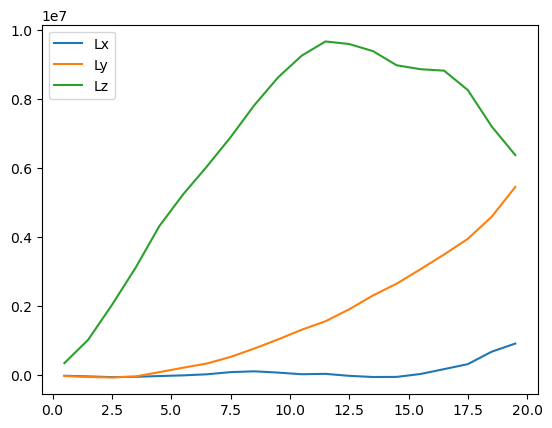

In [21]:
# Plotting mean angular momentum components vs radius

plt.plot(dists,mean_lx,label='Lx') 
plt.plot(dists,mean_ly,label='Ly') 
plt.plot(dists,mean_lz,label='Lz')
plt.legend()

Text(0, 0.5, 'Mean Angular Momentum [kpc km/s]')

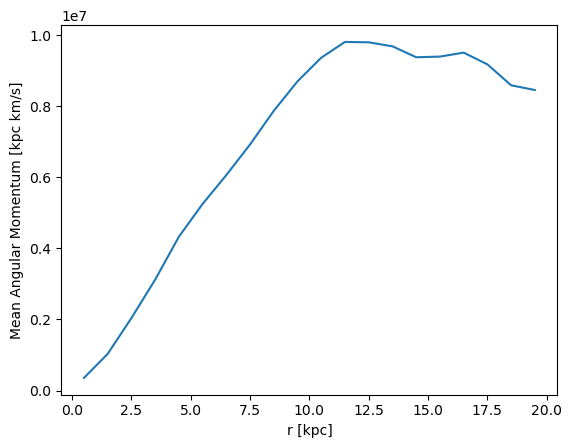

In [22]:
L_profile_mag=np.sqrt(mean_lx**2+mean_ly**2+mean_lz**2) # Magnitude of mean angular momentum vector
plt.plot(dists,L_profile_mag,label='|L|') # Plotting magnitude of mean angular momentum vector
plt.xlabel('r [kpc]') 
plt.ylabel('Mean Angular Momentum [kpc km/s]')

Text(0, 0.5, '$\\theta$ [degrees]')

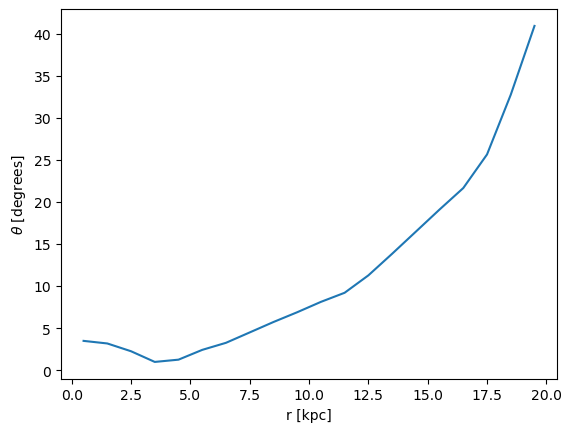

In [23]:
theta=np.arccos(np.divide(mean_lz,L_profile_mag, out=np.zeros_like(L_profile_mag), where=L_profile_mag>0))*(180/np.pi)
plt.plot(dists,theta,label='theta')
plt.xlabel('r [kpc]')
plt.ylabel(r'$\theta$ [degrees]')

In [25]:

prof_mass = SpeciesProfile.get_statistics_profile(properties=mass,distances=r) 
mean_mass=prof_mass['average']
# print(len(theta))
# print(len(dists))
# print(len(mean_mass))
# print(len(r))

# num = np.sum(theta * mean_mass)
# den = np.sum(mean_mass)

num = np.sum(theta * mean_mass)
den = np.sum(mean_mass)

theta_fin = num / den
print(theta_fin)

# plt.plot(theta_fin, dists)
# plt.plot(dists, theta_fin)
# plt.show()

# plot mass v radius as well as theta 

  input 12871441 distances - 10729523 (83.4%) are within limits = [0.000, 20.000]


11.31360239333953
